<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 50%,#312e81 100%);padding:40px;border-radius:14px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;">

<h1 style="margin:0;font-size:42px;letter-spacing:1px;">Image Fundamentals</h1>
<h3 style="margin:8px 0 18px 0;font-weight:300;opacity:0.9;">Notebook 02 - NumPy & OpenCV Core</h3>

<p style="font-size:15px;opacity:0.85;margin:0;">Computer Vision Series - for AI Students & AI Engineers</p>
<p style="font-size:13px;opacity:0.7;margin-top:6px;">Prereq: Notebook 01 (Foundations, History & Toolkit)</p>

</div>

---

> **Note:** All content in this notebook (text, structure, code) is for educational purposes. Always verify critical facts and run code in your own environment.

---

### Where we are in the series

| # | Notebook | Status |
|---|---|---|
| 01 | Foundations, History & Modern Toolkit | Done |
| **02** | **Image Fundamentals & NumPy/OpenCV Core** | *You are here* |
| 03 | Image Processing & Filtering | upcoming |
| 04 | Feature Detection (SIFT, ORB, Harris) | upcoming |
| 05 | Classical ML for Vision | upcoming |
| 06+ | Deep Learning, Detection, Segmentation, Generative, VLMs, Deployment | upcoming |

---

### What you'll master in this notebook

1. **Images as NumPy arrays** - slicing, indexing, broadcasting on pixels
2. **Color spaces** - RGB, BGR, HSV, LAB, YCbCr, Grayscale - and when to use each
3. **Geometric transforms** - resize, crop, flip, rotate, affine, perspective (warp)
4. **Histograms** - what they reveal + equalization & CLAHE for contrast
5. **Reading/writing images & video frames** the production way
6. **Mini project** - build a reusable `ImageOps` toolkit class

> Every section is runnable and uses synthetic or generated images so the notebook works offline.


## 1. An Image is Just a NumPy Array

Internalize this and 80% of CV becomes much less mysterious. Every image you'll ever process is a tensor of integers (or floats) shaped like:

| Image type | Shape | Example |
|---|---|---|
| Grayscale | `(H, W)` | `(480, 640)` |
| Color (RGB / BGR) | `(H, W, 3)` | `(480, 640, 3)` |
| Color + alpha | `(H, W, 4)` | RGBA / BGRA |
| Batch of images | `(N, H, W, C)` or `(N, C, H, W)` | PyTorch uses `NCHW` |

**Common gotcha:** OpenCV stores `(H, W)` - height first. But when you describe resolution casually you say `1920x1080` (width x height). Mix them up and your model trains on rotated images.


Shape: (8, 8)
Dtype: uint8
Pixel at (row=0, col=0): 0
Pixel at (row=3, col=4): 190

Raw values (this IS the image):
[[  0  10  20  30  40  50  60  70]
 [ 10  30  50  70  90 110 130 150]
 [ 20  50  80 110 140 170 200 230]
 [ 30  70 110 150 190 230 250 255]
 [ 40  90 140 190 240 250 240 230]
 [ 50 110 170 230 250 220 180 140]
 [ 60 130 200 250 240 180 120  60]
 [ 70 150 230 255 230 140  60   0]]


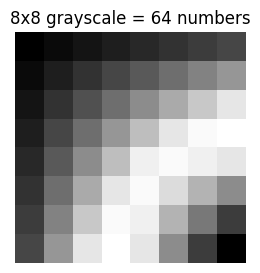

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Build a tiny 8x8 grayscale image manually so we can print it
tiny = np.array([
    [0, 10, 20, 30, 40, 50, 60, 70],
    [10, 30, 50, 70, 90, 110, 130, 150],
    [20, 50, 80, 110, 140, 170, 200, 230],
    [30, 70, 110, 150, 190, 230, 250, 255],
    [40, 90, 140, 190, 240, 250, 240, 230],
    [50, 110, 170, 230, 250, 220, 180, 140],
    [60, 130, 200, 250, 240, 180, 120, 60],
    [70, 150, 230, 255, 230, 140, 60, 0],
], dtype=np.uint8)

print("Shape:", tiny.shape)
print("Dtype:", tiny.dtype)
print("Pixel at (row=0, col=0):", tiny[0, 0])
print("Pixel at (row=3, col=4):", tiny[3, 4])
print()
print("Raw values (this IS the image):")
print(tiny)

plt.figure(figsize=(3, 3))
plt.imshow(tiny, cmap="gray", vmin=0, vmax=255)
plt.title("8x8 grayscale = 64 numbers")
plt.axis("off")
plt.show()

### 1.1 - NumPy slicing on images = ROI extraction

Region-of-interest (ROI) is just array slicing. No special library needed.

```python
roi = img[y1:y2, x1:x2]      # rows then columns - height first
roi = img[y1:y2, x1:x2, :]   # all channels (color image)
red = img[:, :, 0]           # red channel only (RGB)
```


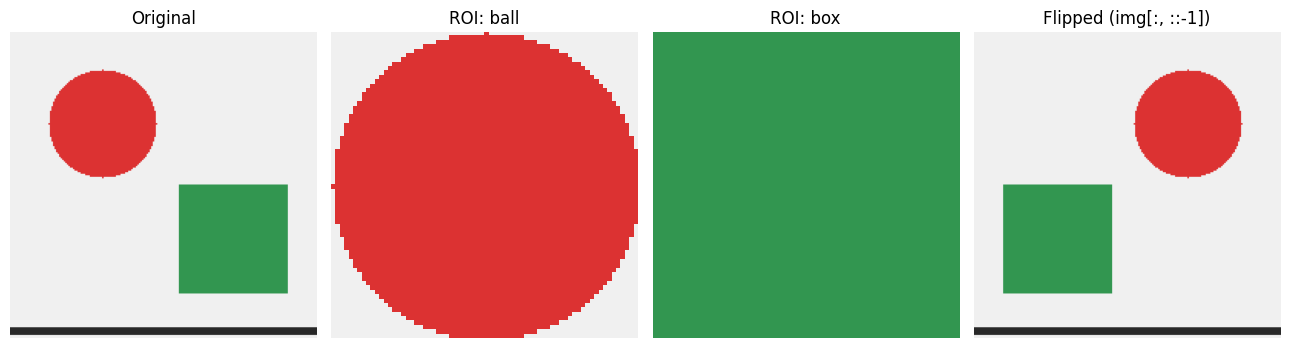

Original size: (200, 200, 3)  Ball ROI: (70, 70, 3)  Box ROI: (70, 70, 3)


In [2]:
# Build a 200x200 RGB image with a synthetic scene
H, W = 200, 200
img = np.full((H, W, 3), 240, dtype=np.uint8)
cv2.circle(img, (60, 60), 35, (220, 50, 50), -1)
cv2.rectangle(img, (110, 100), (180, 170), (50, 150, 80), -1)
cv2.line(img, (0, 195), (199, 195), (40, 40, 40), 4)

# Slice 3 ROIs purely with NumPy
roi_ball = img[25:95, 25:95]
roi_box = img[100:170, 110:180]
roi_diagonal = img[:, ::-1]   # horizontal flip = NumPy stride trick

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
titles = ["Original", "ROI: ball", "ROI: box", "Flipped (img[:, ::-1])"]
for ax, im, t in zip(axes, [img, roi_ball, roi_box, roi_diagonal], titles):
    ax.imshow(im)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Original size:", img.shape, " Ball ROI:", roi_ball.shape, " Box ROI:", roi_box.shape)

## 2. Color Spaces - The Complete Tour

A *color space* is just a coordinate system for color. Choosing the right one can turn a hard problem into a one-liner.

### The five you must know

| Space | Channels | Best for | Notes |
|---|---|---|---|
| **RGB** | Red, Green, Blue | Display, deep learning input | What screens use. Standard format. |
| **BGR** | Blue, Green, Red | OpenCV's default | Same as RGB but reversed. Always convert before showing in matplotlib. |
| **Grayscale** | Single intensity | Edge detection, classical CV, faster compute | 1/3 the data of RGB. |
| **HSV** | Hue, Saturation, Value | Color-based segmentation (e.g., "find all red things") | Hue is robust to lighting. |
| **LAB** | Lightness, a* (green-red), b* (blue-yellow) | Perceptual difference, color correction | L isolates lighting; a/b isolate color. |
| **YCbCr / YUV** | Luma + 2 chroma | Video, JPEG, broadcast | Compresses well; eyes care more about Y than Cb/Cr. |

### Decision tree - which space should I use?

- Need to detect a specific color? -> **HSV** (threshold on Hue)
- Doing classical filters / edges? -> **Grayscale**
- Need perceptual color distance? -> **LAB** (Euclidean distance approx. how different colors look)
- Working with video / compression? -> **YCbCr**
- Feeding a CNN? -> **RGB** float32 in `[0, 1]` (or normalized)


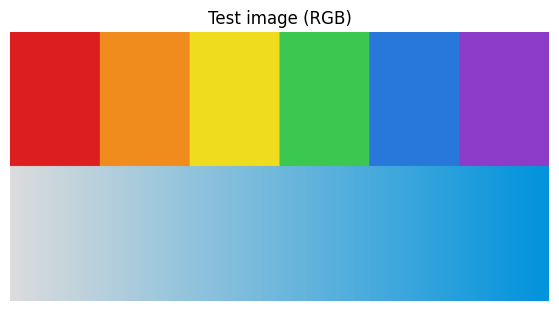

Shape: (180, 360, 3)


In [3]:
# Generate a colorful test image: a row of color patches + a gradient strip
H, W = 180, 360
img_rgb = np.zeros((H, W, 3), dtype=np.uint8)

# Six color patches (top half)
patches = [
    (220, 30, 30), (240, 140, 30), (240, 220, 30),
    (60, 200, 80), (40, 120, 220), (140, 60, 200),
]
patch_w = W // len(patches)
for i, color in enumerate(patches):
    img_rgb[:H//2, i*patch_w:(i+1)*patch_w] = color

# Saturation gradient (bottom half) - same hue, varying saturation
hsv_strip = np.zeros((H//2, W, 3), dtype=np.uint8)
hsv_strip[..., 0] = 100   # constant hue (greenish)
hsv_strip[..., 1] = np.linspace(0, 255, W).astype(np.uint8)[None, :]   # saturation 0-255
hsv_strip[..., 2] = 220   # bright value
img_rgb[H//2:] = cv2.cvtColor(hsv_strip, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(8, 3.5))
plt.imshow(img_rgb)
plt.title("Test image (RGB)")
plt.axis("off")
plt.show()
print("Shape:", img_rgb.shape)

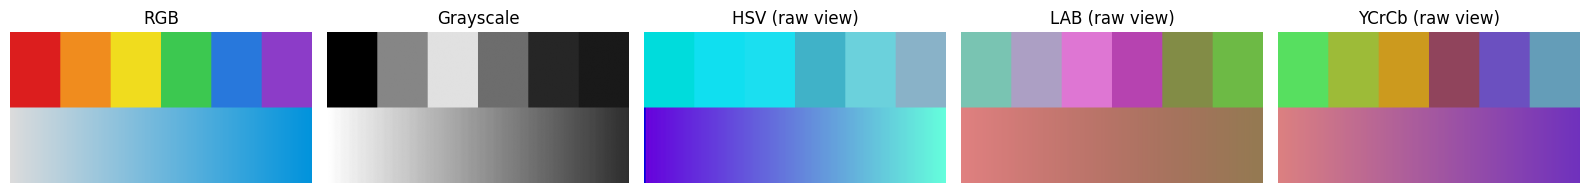

The 'raw view' looks weird because matplotlib renders the channels as if they were RGB.
To understand HSV/LAB/YCrCb, look at the channels separately (next cell).


In [4]:
# Convert the same image into 5 color spaces and visualize
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
ycc = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
axes[0].imshow(img_rgb)
axes[0].set_title("RGB")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[2].imshow(hsv)
axes[2].set_title("HSV (raw view)")
axes[3].imshow(lab)
axes[3].set_title("LAB (raw view)")
axes[4].imshow(ycc)
axes[4].set_title("YCrCb (raw view)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("The 'raw view' looks weird because matplotlib renders the channels as if they were RGB.")
print("To understand HSV/LAB/YCrCb, look at the channels separately (next cell).")

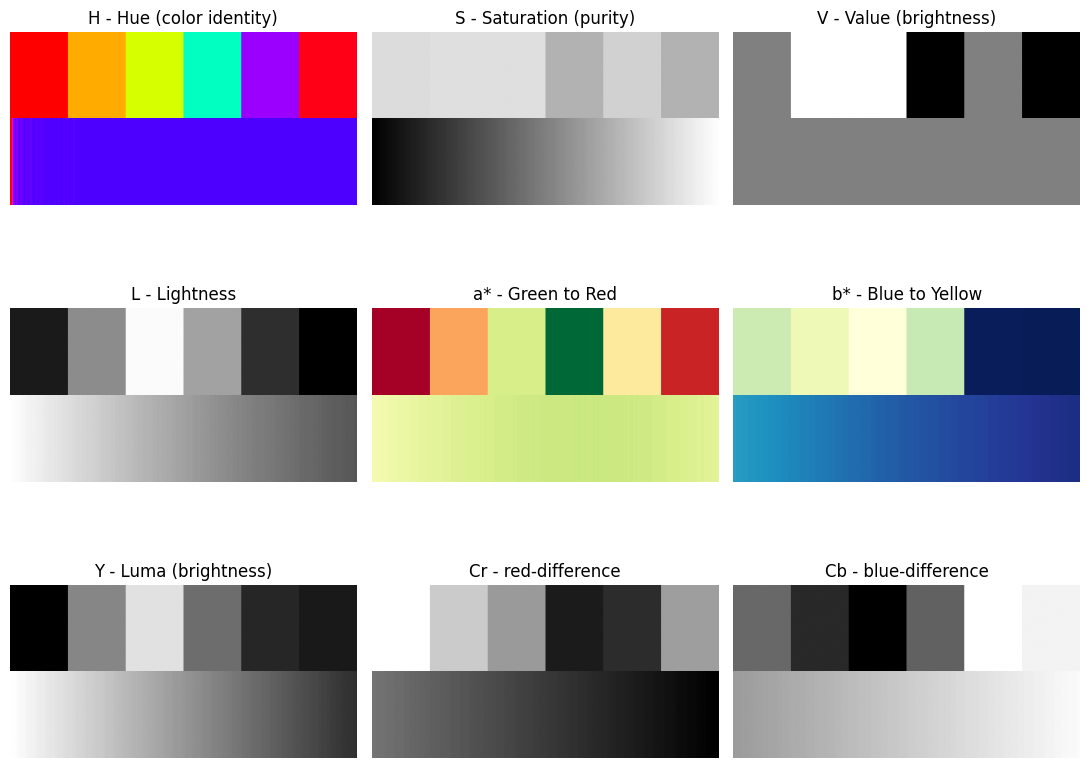

In [5]:
# Split each space into individual channels - this is where the insight lives
fig, axes = plt.subplots(3, 3, figsize=(11, 9))

# HSV
axes[0, 0].imshow(hsv[..., 0], cmap="hsv")
axes[0, 0].set_title("H - Hue (color identity)")
axes[0, 1].imshow(hsv[..., 1], cmap="gray")
axes[0, 1].set_title("S - Saturation (purity)")
axes[0, 2].imshow(hsv[..., 2], cmap="gray")
axes[0, 2].set_title("V - Value (brightness)")

# LAB
axes[1, 0].imshow(lab[..., 0], cmap="gray")
axes[1, 0].set_title("L - Lightness")
axes[1, 1].imshow(lab[..., 1], cmap="RdYlGn_r")
axes[1, 1].set_title("a* - Green to Red")
axes[1, 2].imshow(lab[..., 2], cmap="YlGnBu_r")
axes[1, 2].set_title("b* - Blue to Yellow")

# YCrCb
axes[2, 0].imshow(ycc[..., 0], cmap="gray")
axes[2, 0].set_title("Y - Luma (brightness)")
axes[2, 1].imshow(ycc[..., 1], cmap="gray")
axes[2, 1].set_title("Cr - red-difference")
axes[2, 2].imshow(ycc[..., 2], cmap="gray")
axes[2, 2].set_title("Cb - blue-difference")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.1 - A killer use case: color segmentation in HSV

Try detecting "red pixels" in RGB and you'll fight lighting forever. In HSV you just threshold the **Hue** channel and it works.


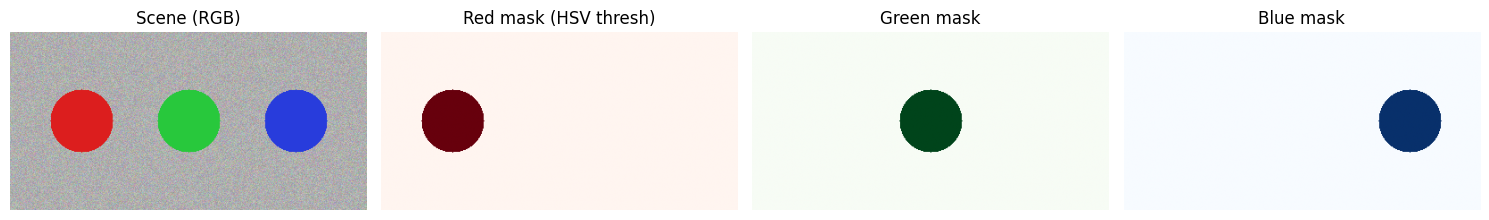

Red pixels: 3853
Green pixels: 3853
Blue pixels: 3853

Tried this in RGB? You'd need 3D thresholds and it'd break the moment lighting changes.


In [6]:
# Build a small scene with red, green, blue blobs on a noisy background
np.random.seed(42)
scene = np.random.randint(150, 200, (200, 400, 3), dtype=np.uint8)
cv2.circle(scene, (80, 100), 35, (220, 30, 30), -1)
cv2.circle(scene, (200, 100), 35, (40, 200, 60), -1)
cv2.circle(scene, (320, 100), 35, (40, 60, 220), -1)

scene_hsv = cv2.cvtColor(scene, cv2.COLOR_RGB2HSV)

# Red wraps around 0 / 180 in OpenCV's H scale, so we need TWO ranges
red_mask = ((scene_hsv[..., 0] <= 10) | (scene_hsv[..., 0] >= 170)) & (scene_hsv[..., 1] > 100)
green_mask = (scene_hsv[..., 0] > 35) & (scene_hsv[..., 0] < 85) & (scene_hsv[..., 1] > 100)
blue_mask = (scene_hsv[..., 0] > 100) & (scene_hsv[..., 0] < 130) & (scene_hsv[..., 1] > 100)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
axes[0].imshow(scene)
axes[0].set_title("Scene (RGB)")
axes[1].imshow(red_mask, cmap="Reds")
axes[1].set_title("Red mask (HSV thresh)")
axes[2].imshow(green_mask, cmap="Greens")
axes[2].set_title("Green mask")
axes[3].imshow(blue_mask, cmap="Blues")
axes[3].set_title("Blue mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Red pixels: {red_mask.sum()}")
print(f"Green pixels: {green_mask.sum()}")
print(f"Blue pixels: {blue_mask.sum()}")
print("\nTried this in RGB? You'd need 3D thresholds and it'd break the moment lighting changes.")

## 3. Geometric Transformations

Every CV pipeline does these. They fall into two families:

| Family | What it does | Examples |
|---|---|---|
| **Pixel-level (no geometry)** | Same shape, change values | Brightness, color shift |
| **Geometric** | Move pixels around | Resize, rotate, warp |

### Geometric transforms - the hierarchy

```
Identity   ->  Translation   ->  Rigid (rotate+translate)
           ->  Similarity    ->  Affine          ->  Projective (Homography)
              (scale+rotate)    (shear, skew)        (perspective warp)
```

Each is a strict superset of the previous. Affine preserves parallel lines, perspective doesn't.


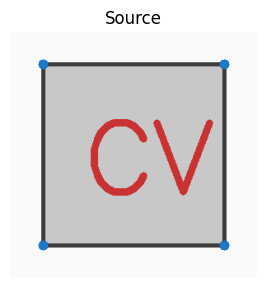

In [7]:
# Make a clean source image to transform
src = np.full((300, 300, 3), 250, dtype=np.uint8)
cv2.rectangle(src, (40, 40), (260, 260), (200, 200, 200), -1)
cv2.rectangle(src, (40, 40), (260, 260), (60, 60, 60), 3)
cv2.putText(src, "CV", (90, 195), cv2.FONT_HERSHEY_SIMPLEX, 4, (200, 50, 50), 8)

# Add corner dots so we can see what each transform does to corners
for pt in [(40, 40), (260, 40), (40, 260), (260, 260)]:
    cv2.circle(src, pt, 6, (30, 120, 200), -1)

plt.figure(figsize=(3.2, 3.2))
plt.imshow(src)
plt.title("Source")
plt.axis("off")
plt.show()

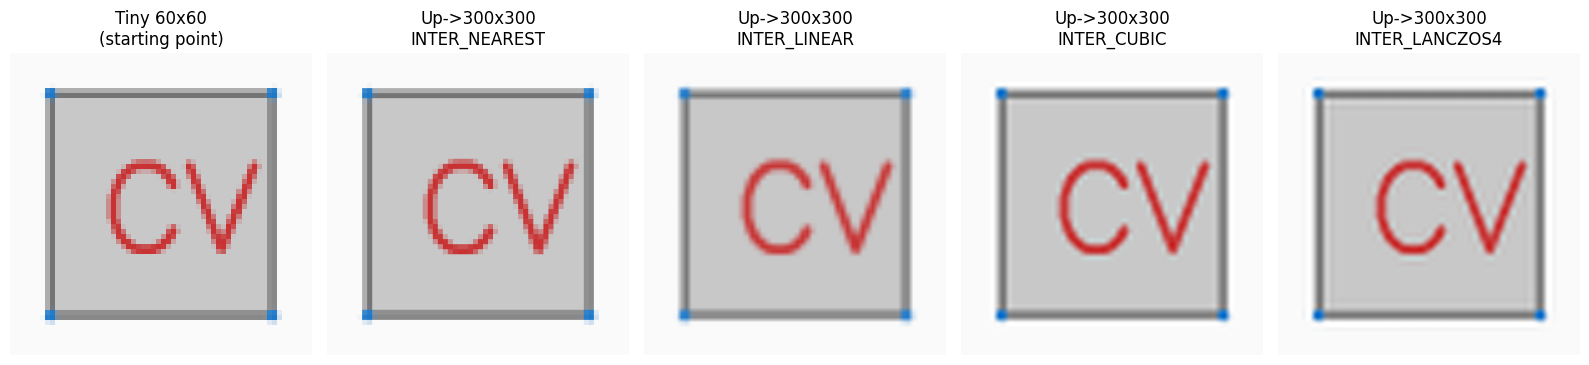

Rules of thumb:
- Downscaling -> INTER_AREA (best for shrinking)
- Upscaling -> INTER_CUBIC or INTER_LANCZOS4
- Need pixel-exact (e.g., labels)? -> INTER_NEAREST


In [8]:
# 3.1 - Resize (4 interpolation methods)
methods = [
    ("INTER_NEAREST", cv2.INTER_NEAREST),
    ("INTER_LINEAR", cv2.INTER_LINEAR),
    ("INTER_CUBIC", cv2.INTER_CUBIC),
    ("INTER_LANCZOS4", cv2.INTER_LANCZOS4),
]

# Show one shrink + interpolation comparison on enlargement (where it matters most)
small = cv2.resize(src, (60, 60), interpolation=cv2.INTER_AREA)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(small)
axes[0].set_title("Tiny 60x60\n(starting point)")
axes[0].axis("off")

for ax, (name, m) in zip(axes[1:], methods):
    enlarged = cv2.resize(small, (300, 300), interpolation=m)
    ax.imshow(enlarged)
    ax.set_title(f"Up->300x300\n{name}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Rules of thumb:")
print("- Downscaling -> INTER_AREA (best for shrinking)")
print("- Upscaling -> INTER_CUBIC or INTER_LANCZOS4")
print("- Need pixel-exact (e.g., labels)? -> INTER_NEAREST")

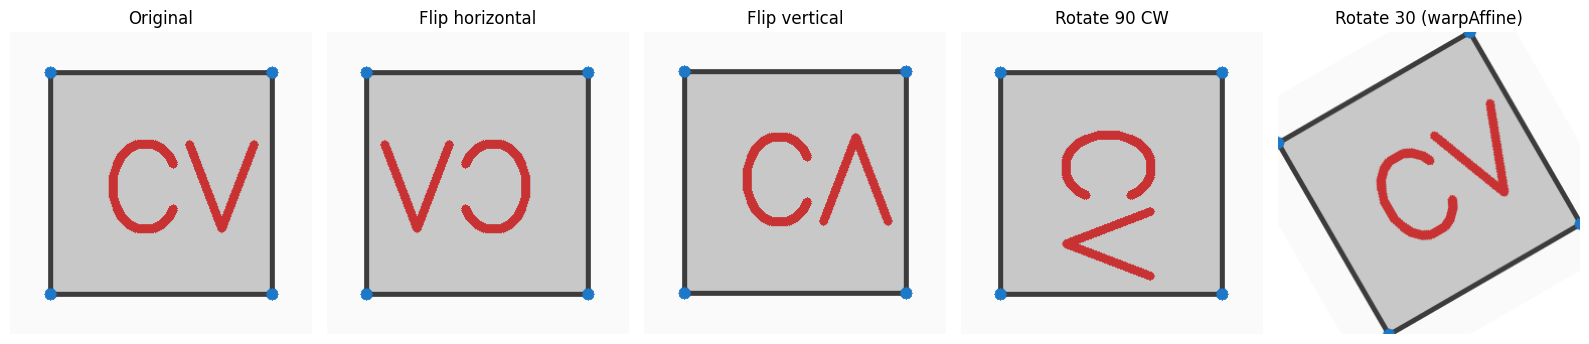

In [9]:
# 3.2 - Flip & Rotate
flipped_h = cv2.flip(src, 1)   # horizontal
flipped_v = cv2.flip(src, 0)   # vertical
rotated_90 = cv2.rotate(src, cv2.ROTATE_90_CLOCKWISE)

# Free-angle rotation: build a 2x3 rotation matrix and use warpAffine
center = (src.shape[1] // 2, src.shape[0] // 2)
M = cv2.getRotationMatrix2D(center, angle=30, scale=1.0)
rotated_30 = cv2.warpAffine(src, M, (src.shape[1], src.shape[0]), borderValue=(255, 255, 255))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
titles = ["Original", "Flip horizontal", "Flip vertical", "Rotate 90 CW", "Rotate 30 (warpAffine)"]
images = [src, flipped_h, flipped_v, rotated_90, rotated_30]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

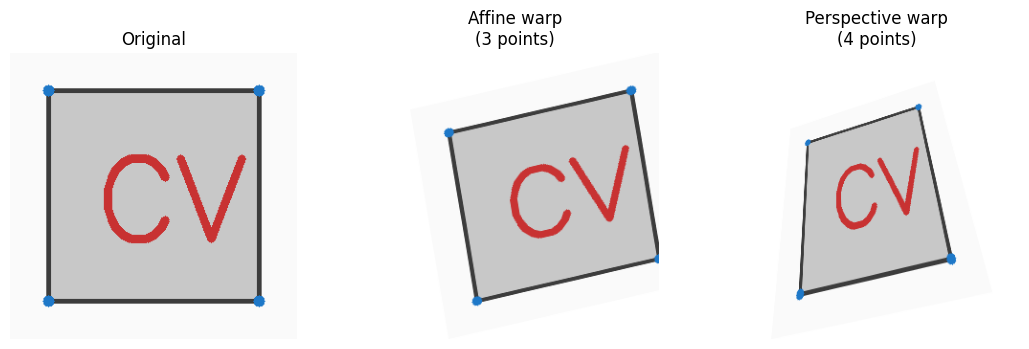

Affine matrix (2x3):
[[ 0.87  0.13 40.  ]
 [-0.2   0.8  60.  ]]

Perspective matrix (3x3):
[[ 0.45 -0.11 60.  ]
 [-0.18  0.4  80.  ]
 [-0.   -0.    1.  ]]

Perspective warp is the math behind 'document scanner' apps that flatten a tilted page.


In [10]:
# 3.3 - Affine warp (parallel lines preserved)
h, w = src.shape[:2]
src_pts = np.float32([[0, 0], [w-1, 0], [0, h-1]])
dst_pts = np.float32([[40, 60], [w-1, 0], [80, h-1]])

M_aff = cv2.getAffineTransform(src_pts, dst_pts)
affined = cv2.warpAffine(src, M_aff, (w, h), borderValue=(255, 255, 255))

# 3.4 - Perspective warp (parallel lines NOT preserved - true 3D-ish effect)
src_pts4 = np.float32([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]])
dst_pts4 = np.float32([[60, 80], [w-90, 30], [w-30, h-50], [40, h-1]])

M_per = cv2.getPerspectiveTransform(src_pts4, dst_pts4)
perspectived = cv2.warpPerspective(src, M_per, (w, h), borderValue=(255, 255, 255))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(src)
axes[0].set_title("Original")
axes[1].imshow(affined)
axes[1].set_title("Affine warp\n(3 points)")
axes[2].imshow(perspectived)
axes[2].set_title("Perspective warp\n(4 points)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Affine matrix (2x3):")
print(M_aff.round(2))
print("\nPerspective matrix (3x3):")
print(M_per.round(2))
print("\nPerspective warp is the math behind 'document scanner' apps that flatten a tilted page.")

## 4. Histograms - The Statistical X-Ray of an Image

A histogram counts how many pixels have each intensity. From it, you can immediately tell:

- Dark image -> values clustered near 0
- Bright image -> values clustered near 255
- Low contrast -> values squished into a narrow range
- Bimodal histogram -> suggests foreground + background -> easy thresholding (Otsu's method)

We'll use it for two things now:

1. Diagnose image quality
2. Fix it with histogram equalization & CLAHE


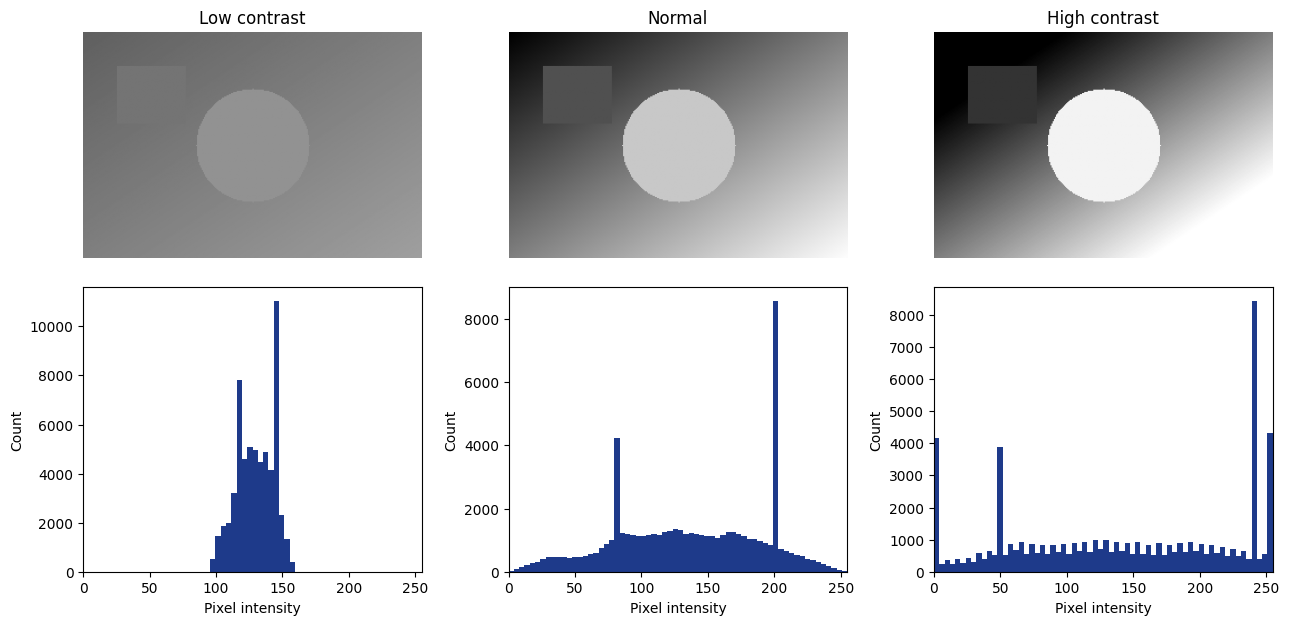

The histogram tells you the story of the image's tonal range BEFORE you even look at it.


In [11]:
# Build three versions of the same scene: low-contrast, normal, high-contrast
base = np.zeros((200, 300), dtype=np.uint8)
yy, xx = np.mgrid[0:200, 0:300]
base = (((xx / 300 + yy / 200) / 2) * 255).astype(np.uint8)
cv2.circle(base, (150, 100), 50, 200, -1)
cv2.rectangle(base, (30, 30), (90, 80), 80, -1)

# Squash dynamic range (low contrast)
low_contrast = ((base.astype(np.float32) - 128) * 0.25 + 128).clip(0, 255).astype(np.uint8)

# Stretch dynamic range (high contrast)
high_contrast = ((base.astype(np.float32) - 128) * 1.6 + 128).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
variants = [(low_contrast, "Low contrast"), (base, "Normal"), (high_contrast, "High contrast")]
for col, (im, title) in enumerate(variants):
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(im.ravel(), bins=64, range=(0, 255), color="#1e3a8a")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Pixel intensity")
    axes[1, col].set_ylabel("Count")
plt.tight_layout()
plt.show()

print("The histogram tells you the story of the image's tonal range BEFORE you even look at it.")

### 4.1 - Histogram equalization vs. CLAHE

| Method | What it does | When it shines | Risk |
|---|---|---|---|
| **Global histogram equalization** | Stretches histogram across full 0-255 range | Globally dark/washed images | Can over-amplify noise; ignores local contrast |
| **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) | Equalizes in small tiles, with a clip limit to prevent noise blow-up | Medical imaging, foggy/uneven-lit photos | Slightly slower, needs tuning |

**Rule of thumb in 2026:** for natural images, always reach for CLAHE first.


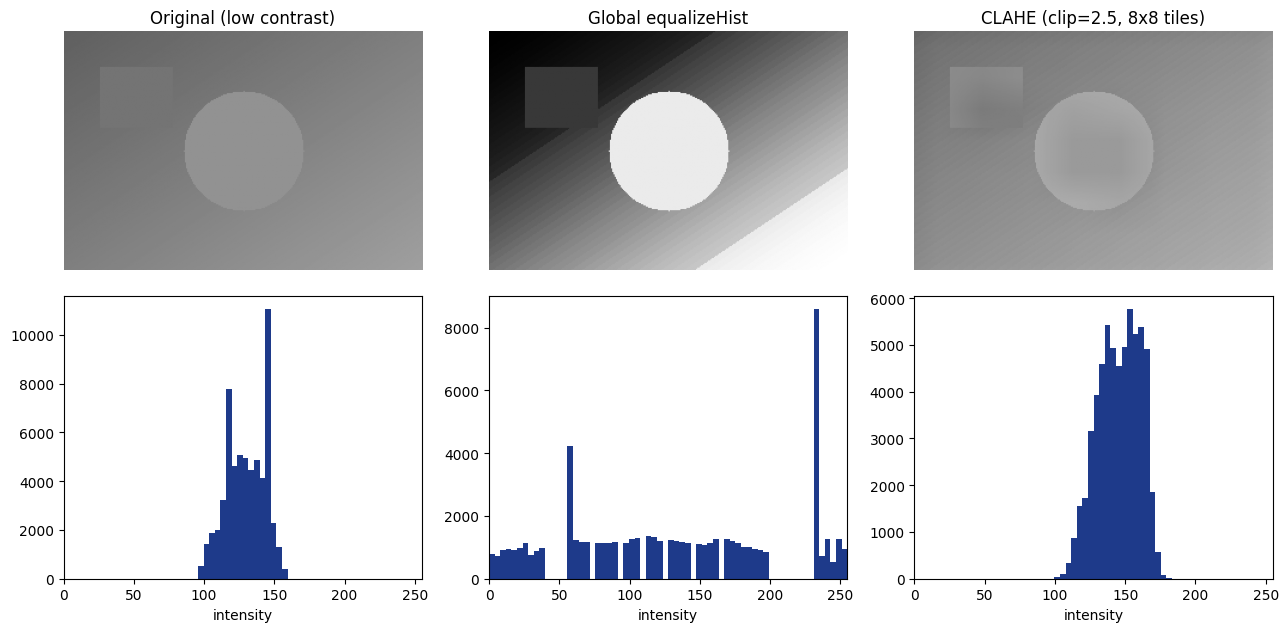

In [12]:
# Apply both methods to the low-contrast image
eq_global = cv2.equalizeHist(low_contrast)

clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
eq_clahe = clahe.apply(low_contrast)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
variants = [
    (low_contrast, "Original (low contrast)"),
    (eq_global, "Global equalizeHist"),
    (eq_clahe, "CLAHE (clip=2.5, 8x8 tiles)"),
]
for col, (im, title) in enumerate(variants):
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(im.ravel(), bins=64, range=(0, 255), color="#1e3a8a")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("intensity")
plt.tight_layout()
plt.show()

### 4.2 - Equalizing color images: never on RGB

Equalizing each RGB channel separately shifts colors. The professional move:

1. Convert to a space where lightness is its own channel (LAB or YCrCb)
2. Equalize only the L (or Y) channel
3. Convert back


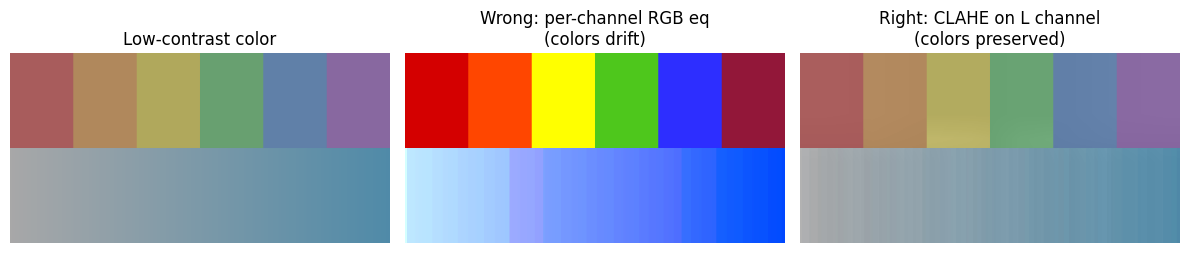

In [13]:
# Make a low-contrast color image
color_low = (img_rgb.astype(np.float32) * 0.4 + 80).clip(0, 255).astype(np.uint8)

# Wrong way: equalize each RGB channel independently
wrong = color_low.copy()
for c in range(3):
    wrong[..., c] = cv2.equalizeHist(wrong[..., c])

# Right way: equalize the L channel of LAB
lab_low = cv2.cvtColor(color_low, cv2.COLOR_RGB2LAB)
lab_low[..., 0] = clahe.apply(lab_low[..., 0])
right = cv2.cvtColor(lab_low, cv2.COLOR_LAB2RGB)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(color_low)
axes[0].set_title("Low-contrast color")
axes[1].imshow(wrong)
axes[1].set_title("Wrong: per-channel RGB eq\n(colors drift)")
axes[2].imshow(right)
axes[2].set_title("Right: CLAHE on L channel\n(colors preserved)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Reading & Writing - The Production Way

### Image I/O

| Tool | Read | Write | Notes |
|---|---|---|---|
| `cv2.imread(path)` | BGR by default | `cv2.imwrite()` | Returns `None` on failure - always check |
| `PIL.Image.open(path)` | RGB by default | `.save()` | Better for non-natural formats (TIFF, GIF) |
| `skimage.io.imread()` | RGB | `imsave` | Scientific-friendly |

### The 4 most common I/O bugs

1. **Path doesn't exist** -> `imread` silently returns `None`. Check before using.
2. **Unicode / non-ASCII paths** on Windows -> `imread` fails. Workaround: read bytes then `cv2.imdecode`.
3. **BGR vs RGB confusion** -> image looks blue-tinted in matplotlib. Always convert.
4. **Large images** -> `imread` loads the whole file. For huge images, use tiled libraries like `pyvips` or `tifffile`.


In [14]:
import os
import tempfile

# Make a temp directory we can read/write into
tmp = tempfile.mkdtemp()
print("Temp dir:", tmp)

# Write our test image in 3 formats and compare file sizes
paths = {
    "PNG (lossless)": os.path.join(tmp, "test.png"),
    "JPEG q=90": os.path.join(tmp, "test_q90.jpg"),
    "JPEG q=20": os.path.join(tmp, "test_q20.jpg"),
}

# OpenCV writes BGR, so convert from RGB first
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

cv2.imwrite(paths["PNG (lossless)"], img_bgr)
cv2.imwrite(paths["JPEG q=90"], img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 90])
cv2.imwrite(paths["JPEG q=20"], img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 20])

raw_size = img_rgb.nbytes
print(f"\n{'Format':<20}{'Size (bytes)':>14}{'Compression ratio':>22}")
print("-" * 56)
for name, p in paths.items():
    size = os.path.getsize(p)
    print(f"{name:<20}{size:>14,}{raw_size/size:>20.1f}x")
print(f"{'(raw NumPy bytes)':<20}{raw_size:>14,}")

Temp dir: /var/folders/gv/j2_rqyzs6xxc8hq136dzsvnc0000gn/T/tmpmy93c_40

Format                Size (bytes)     Compression ratio
--------------------------------------------------------
PNG (lossless)              18,834                10.3x
JPEG q=90                    4,951                39.3x
JPEG q=20                    2,279                85.3x
(raw NumPy bytes)          194,400


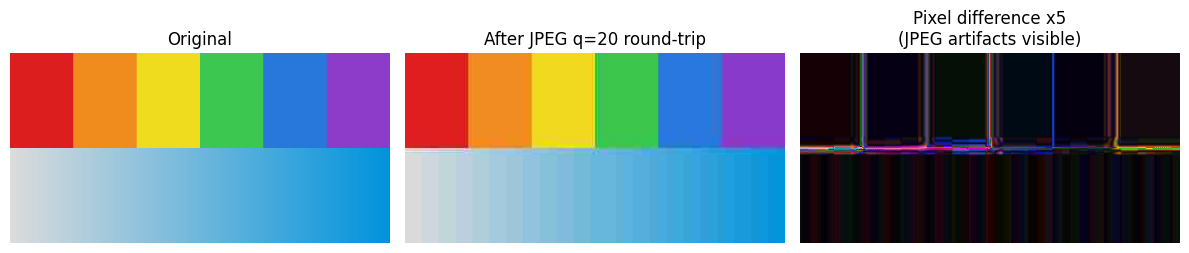

Mean absolute pixel diff: 3.54
JPEG is lossy. PNG is lossless. Choose based on your need (storage vs fidelity).


In [15]:
# Read back & visualize the JPEG-q20 to see compression artifacts
loaded_bgr = cv2.imread(paths["JPEG q=20"])

# Safety check - always do this in production code
if loaded_bgr is None:
    raise FileNotFoundError(f"Could not read image at {paths['JPEG q=20']}")

loaded_rgb = cv2.cvtColor(loaded_bgr, cv2.COLOR_BGR2RGB)

# Show the difference
diff = cv2.absdiff(img_rgb, loaded_rgb)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[1].imshow(loaded_rgb)
axes[1].set_title("After JPEG q=20 round-trip")
axes[2].imshow(diff * 5)
axes[2].set_title("Pixel difference x5\n(JPEG artifacts visible)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Mean absolute pixel diff: {diff.mean():.2f}")
print("JPEG is lossy. PNG is lossless. Choose based on your need (storage vs fidelity).")

### 5.1 - Working with video frames

Video = sequence of images at a fixed framerate. OpenCV exposes it as a stream.

```python
cap = cv2.VideoCapture("input.mp4")   # or 0 for webcam
while True:
    ok, frame = cap.read()            # frame is a BGR ndarray
    if not ok:
        break
    # ... process frame ...
cap.release()
```

We can't run live video in a notebook reliably, so let's synthesize a 24-frame "video" and process each frame the way you would in production.


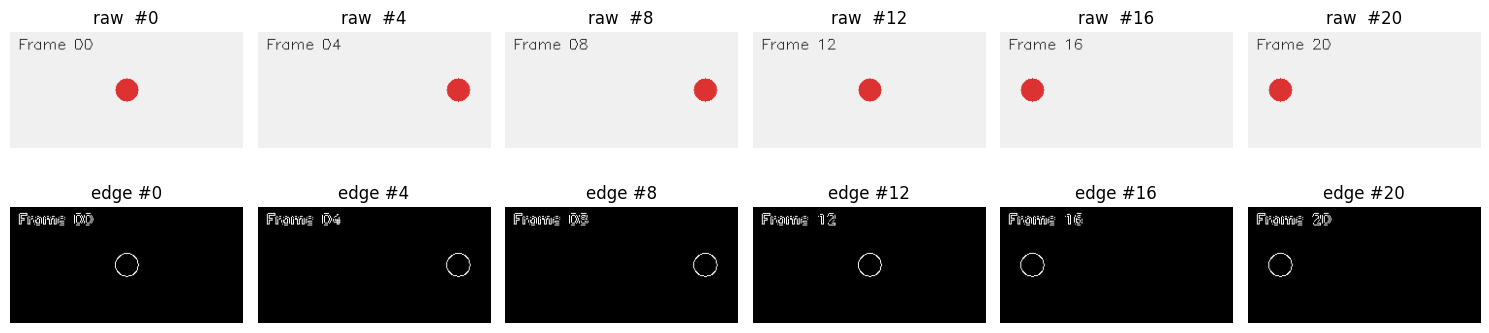

Processed 24 frames at 120x240 -> produced edge maps in real time.


In [16]:
# Synthesize a 24-frame video sequence: a ball bouncing horizontally
N_FRAMES = 24
H, W = 120, 240
frames = []
for i in range(N_FRAMES):
    f = np.full((H, W, 3), 240, dtype=np.uint8)
    x = int(20 + (W - 40) * (0.5 + 0.5 * np.sin(2 * np.pi * i / N_FRAMES)))
    cv2.circle(f, (x, H // 2), 12, (220, 50, 50), -1)
    cv2.putText(f, f"Frame {i:02d}", (8, 18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (40, 40, 40), 1)
    frames.append(f)

# Per-frame processing (the same loop you'd use for real video)
processed = []
for f in frames:
    gray = cv2.cvtColor(f, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 80, 180)
    processed.append(edges)

# Display every 4th frame to show motion
fig, axes = plt.subplots(2, 6, figsize=(15, 4))
for i, idx in enumerate(range(0, N_FRAMES, 4)):
    axes[0, i].imshow(frames[idx])
    axes[0, i].set_title(f"raw  #{idx}")
    axes[0, i].axis("off")
    axes[1, i].imshow(processed[idx], cmap="gray")
    axes[1, i].set_title(f"edge #{idx}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

print(f"Processed {N_FRAMES} frames at {H}x{W} -> produced edge maps in real time.")

## 6. Mini Project - A Reusable `ImageOps` Toolkit

Time to package what we've learned into a clean class you can drop into any future notebook in this series.

**Design goals:**

- Method-chaining API (fluent style)
- Always works on a copy (never mutates the input)
- One-line conversion to/from disk
- Sensible defaults


Pipeline result: <ImageOps shape=(110, 220, 3) dtype=uint8>


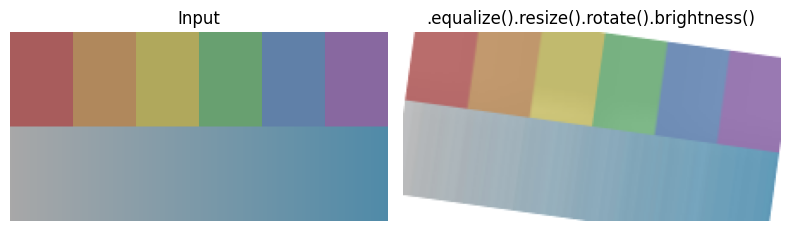

In [17]:
class ImageOps:
    """
    Fluent image-processing toolkit. All operations return a NEW ImageOps
    so you can chain: ImageOps(img).resize(...).gray().equalize().array.

    Internal storage is always RGB uint8.
    """

    # ---- construction ----
    def __init__(self, array: np.ndarray):
        if array.dtype != np.uint8:
            array = np.clip(array, 0, 255).astype(np.uint8)
        self.array = array

    @classmethod
    def from_file(cls, path: str) -> "ImageOps":
        bgr = cv2.imread(path)
        if bgr is None:
            raise FileNotFoundError(f"Could not read {path}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB) if bgr.ndim == 3 else bgr
        return cls(rgb)

    def save(self, path: str, jpeg_quality: int = 95) -> "ImageOps":
        out = self.array
        if out.ndim == 3:
            out = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        params = []
        if path.lower().endswith((".jpg", ".jpeg")):
            params = [cv2.IMWRITE_JPEG_QUALITY, jpeg_quality]
        cv2.imwrite(path, out, params)
        return self

    # ---- introspection ----
    @property
    def shape(self):
        return self.array.shape

    def __repr__(self):
        return f"<ImageOps shape={self.array.shape} dtype={self.array.dtype}>"

    # ---- color ----
    def gray(self) -> "ImageOps":
        if self.array.ndim == 2:
            return ImageOps(self.array.copy())
        return ImageOps(cv2.cvtColor(self.array, cv2.COLOR_RGB2GRAY))

    def to_hsv(self) -> "ImageOps":
        return ImageOps(cv2.cvtColor(self.array, cv2.COLOR_RGB2HSV))

    # ---- geometry ----
    def resize(self, width: int, height: int, mode: str = "auto") -> "ImageOps":
        cur_h, cur_w = self.array.shape[:2]
        if mode == "auto":
            interp = cv2.INTER_AREA if (width * height) < (cur_w * cur_h) else cv2.INTER_CUBIC
        else:
            mapping = {
                "nearest": cv2.INTER_NEAREST,
                "linear": cv2.INTER_LINEAR,
                "cubic": cv2.INTER_CUBIC,
                "lanczos": cv2.INTER_LANCZOS4,
            }
            interp = mapping[mode]
        return ImageOps(cv2.resize(self.array, (width, height), interpolation=interp))

    def crop(self, x: int, y: int, w: int, h: int) -> "ImageOps":
        return ImageOps(self.array[y:y+h, x:x+w].copy())

    def rotate(self, angle: float) -> "ImageOps":
        h, w = self.array.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        return ImageOps(cv2.warpAffine(self.array, M, (w, h), borderValue=(255,)*3))

    def flip(self, axis: str = "h") -> "ImageOps":
        return ImageOps(cv2.flip(self.array, 1 if axis == "h" else 0))

    # ---- enhancement ----
    def equalize(self) -> "ImageOps":
        if self.array.ndim == 2:
            return ImageOps(cv2.equalizeHist(self.array))
        lab = cv2.cvtColor(self.array, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        lab[..., 0] = clahe.apply(lab[..., 0])
        return ImageOps(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

    def brightness(self, delta: int) -> "ImageOps":
        return ImageOps(np.clip(self.array.astype(np.int16) + delta, 0, 255))


# ---- demo: chain a full pipeline in one line ----
pipeline = (
    ImageOps(color_low)
    .equalize()
    .resize(220, 110)
    .rotate(-8)
    .brightness(15)
)

print("Pipeline result:", pipeline)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
axes[0].imshow(color_low)
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(pipeline.array)
axes[1].set_title(".equalize().resize().rotate().brightness()")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [18]:
# Save & reload to prove the I/O methods work end-to-end
out_path = os.path.join(tmp, "pipeline_result.jpg")
pipeline.save(out_path, jpeg_quality=92)

print(f"Saved -> {out_path} ({os.path.getsize(out_path):,} bytes)")
reloaded = ImageOps.from_file(out_path)
print(f"Reloaded -> {reloaded}")

Saved -> /var/folders/gv/j2_rqyzs6xxc8hq136dzsvnc0000gn/T/tmpmy93c_40/pipeline_result.jpg (3,874 bytes)
Reloaded -> <ImageOps shape=(110, 220, 3) dtype=uint8>


## 7. Recap

- **Images are NumPy arrays** - slicing = ROI, broadcasting = pixel ops
- **Six color spaces** with concrete *when-to-use* rules
- **HSV color segmentation** - the trick every CV engineer should know
- **Geometric transforms** - resize (with the right interpolation), flip, rotate, affine, perspective
- **Histograms** to diagnose images, **CLAHE** to fix them - and never equalize RGB directly
- **Production-grade I/O** - JPEG vs PNG trade-offs, error handling, video frame loop
- **Built `ImageOps`** - a fluent, chainable toolkit you'll reuse in later notebooks

### One-line takeaway

> **Master the array, master the color space, master the transform - and 90% of "image processing problems" become 3-line solutions.**

---

### Coming next: Notebook 03 - Image Processing & Filtering

We'll go deep on:

- Convolution mathematics (the operation behind every CNN)
- Smoothing filters: mean, Gaussian, bilateral, median
- Sharpening, unsharp masking, high-pass filtering
- Edge detection in depth: Sobel, Scharr, Laplacian, Canny
- Morphological operations: erosion, dilation, opening, closing, top-hat
- Building a license-plate-cleanup pipeline as a capstone

---

<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 100%);padding:18px;border-radius:10px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;margin-top:18px;">
<b>End of Notebook 02 - Computer Vision Series - 2025-2026</b><br>
<span style="opacity:0.8;font-size:13px;">You can now manipulate any image. Next stop: making them smarter.</span>
</div>